# 4. Distributions

A distribution is not a shape to match — it is a hypothesis about the process that
generated the data. "Lognormal with μ=3.2, σ=0.8" describes the data; it also implies
the data is a *product* of many factors, which is a claim you can check against what you
know about how it was produced. This notebook builds that habit before it matters: what
each family looks like generated, where the textbook shapes come from, and where the
IRC corpus is too coarse to ask the question at all.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from goad_toolkit.distributions import DistributionRegistry
from goad_toolkit.analytics import DistributionFitter, fit_table
from goad_toolkit.visualizer import (
    DistPlot,
    HistogramPlot,
    PlotSettings,
    QQPlot,
)

from wa_analyzer.data import load_own_chat, load_showcase

rng = np.random.default_rng(42)

## 4.1 Generated families, before real data is involved

Six families, each sampled from a known generator, so what you see on screen is *only*
the shape — no fitting, no noise from "did we estimate the parameters right".

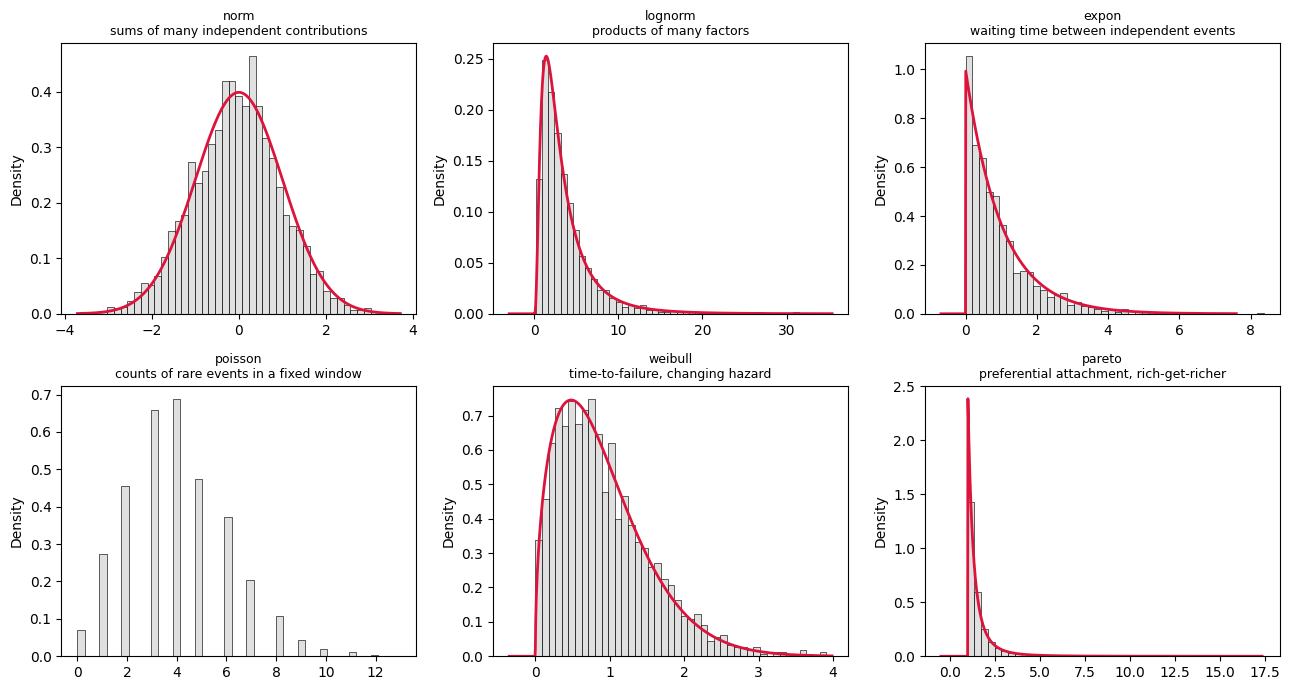

In [2]:
families = [
    ("norm", stats.norm(loc=0, scale=1), "sums of many independent contributions"),
    ("lognorm", stats.lognorm(s=0.8, scale=np.exp(1)), "products of many factors"),
    ("expon", stats.expon(scale=1), "waiting time between independent events"),
    ("poisson", stats.poisson(mu=4), "counts of rare events in a fixed window"),
    ("weibull", stats.weibull_min(c=1.5, scale=1), "time-to-failure, changing hazard"),
    ("pareto", stats.pareto(b=2.5), "preferential attachment, rich-get-richer"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, dist, mechanism) in zip(axes.flat, families):
    is_discrete = name == "poisson"
    sample = dist.rvs(2000, random_state=rng)
    host = HistogramPlot(PlotSettings())
    host.fig, host.ax = fig, ax
    host.build(sample, kde=False, color="lightgrey")
    if not is_discrete:
        curve = DistPlot(PlotSettings())
        curve.fig, curve.ax = fig, ax
        curve.build(dist, color="crimson", linewidth=2)
    ax.set_title(f"{name}\n{mechanism}", fontsize=9)

fig.tight_layout()

`poisson` has no continuous pdf to overlay — the bars are the whole picture, which is the
point: a discrete count does not have a density, only a mass at each integer.

## 4.2 The central limit theorem — sums converge, nothing else has to

Sums of *anything* with finite variance drift toward normal as you add more terms. That is
why normal turns up everywhere sums turn up — and it says nothing at all about products,
waiting times, or counts, which converge to something else entirely (lognormal, gamma,
Poisson) precisely because they are not sums.

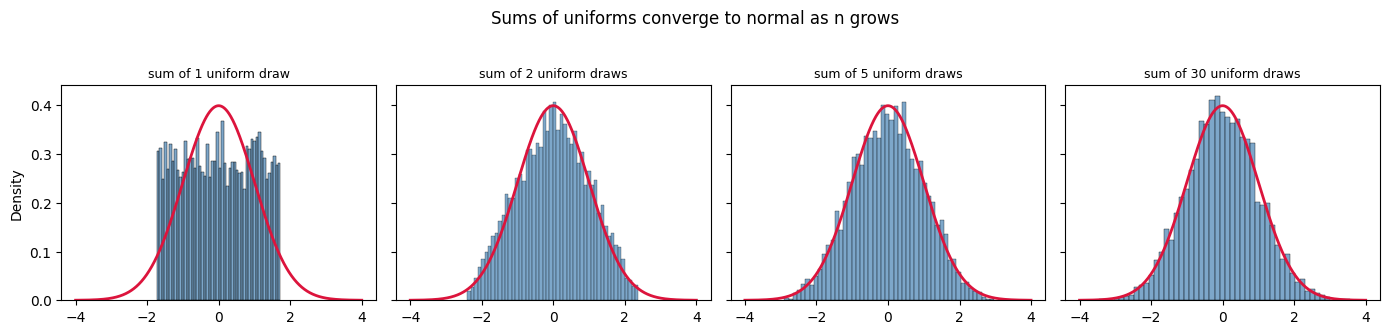

In [3]:
ns = [1, 2, 5, 30]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True, sharey=True)
for ax, n in zip(axes, ns):
    sums = stats.uniform(loc=-1, scale=2).rvs((5000, n), random_state=rng).sum(axis=1)
    sums = (sums - sums.mean()) / sums.std()
    host = HistogramPlot(PlotSettings())
    host.fig, host.ax = fig, ax
    host.build(sums, color="steelblue")
    curve = DistPlot(PlotSettings())
    curve.fig, curve.ax = fig, ax
    curve.build(stats.norm(0, 1), color="crimson", x_range=(-4, 4))
    ax.set_title(f"sum of {n} uniform draw{'s' if n > 1 else ''}", fontsize=9)
fig.suptitle("Sums of uniforms converge to normal as n grows", y=1.03)
fig.tight_layout()

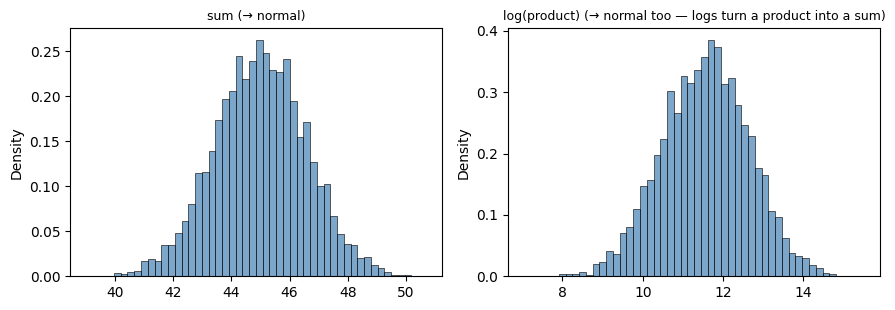

In [4]:
# Contrast: a PRODUCT of the same uniforms does not converge to normal at all —
# it converges to lognormal, because a sum of logs is a sum, and exp() of a sum is
# a product. The CLT is a statement about sums specifically.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
n = 30
sums = stats.uniform(loc=1, scale=1).rvs((5000, n), random_state=rng).sum(axis=1)
products = stats.uniform(loc=1, scale=1).rvs((5000, n), random_state=rng).prod(axis=1)

for ax, values, title in zip(axes, [sums, np.log(products)], ["sum (→ normal)", "log(product) (→ normal too — logs turn a product into a sum)"]):
    host = HistogramPlot(PlotSettings())
    host.fig, host.ax = fig, ax
    host.build(values, color="steelblue")
    ax.set_title(title, fontsize=9)
fig.tight_layout()

The right panel is `log(product)`, not `product` — that is the whole trick lognormal is
named for. Plot `products` directly and it is skewed and long-tailed, not bell-shaped,
because a product of positive numbers is exactly the kind of variable the CLT does not
apply to directly.

## 4.3 The long tail, on taxi fares

`taxis`: 6,433 NYC rides. `fare` has no zeros, which `distance` does, so it is the one to
log-transform.

In [5]:
taxis = load_showcase("taxis")
fare = taxis["fare"].to_numpy()

print(f"mean:   {fare.mean():.2f}")
print(f"median: {np.median(fare):.2f}")
print("the mean is pulled up by the tail; for a symmetric distribution the two would match")

mean:   13.09
median: 9.50
the mean is pulled up by the tail; for a symmetric distribution the two would match


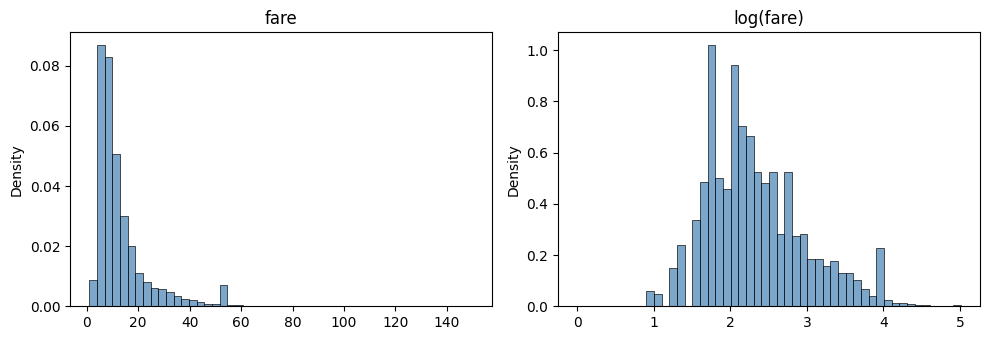

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
host = HistogramPlot(PlotSettings())
host.fig, host.ax = fig, axes[0]
host.build(fare, color="steelblue")
axes[0].set_title("fare")

host2 = HistogramPlot(PlotSettings())
host2.fig, host2.ax = fig, axes[1]
host2.build(np.log(fare), color="steelblue")
axes[1].set_title("log(fare)")
fig.tight_layout()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'fare vs. fitted lognormal'}, xlabel='X', ylabel='Y'>)

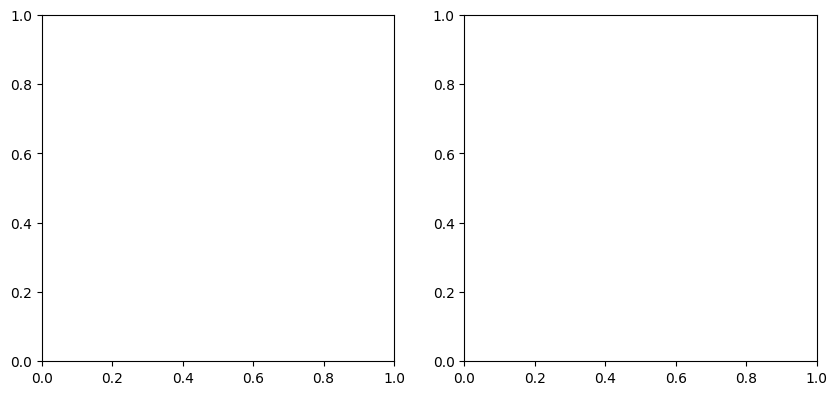

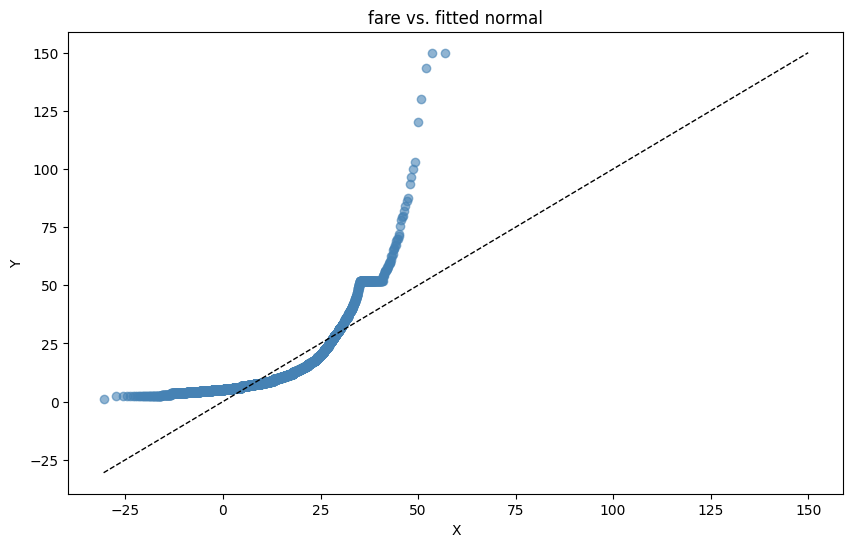

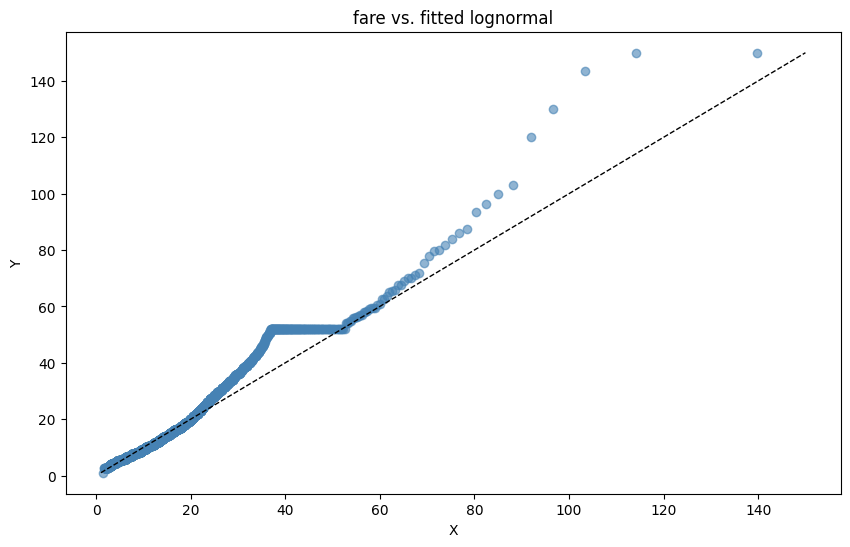

In [7]:
# Does normal fit the raw fare, or does lognormal fit it once we account for the log?
registry = DistributionRegistry()
fitter = DistributionFitter(registry)

norm_fit = fitter.fit_distribution("norm", fare)
lognorm_fit = fitter.fit_distribution("lognorm", fare)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
QQPlot(PlotSettings(title="fare vs. fitted normal")).plot(
    data=fare, distribution=norm_fit.frozen_dist,
)
QQPlot(PlotSettings(title="fare vs. fitted lognormal")).plot(
    data=fare, distribution=lognorm_fit.frozen_dist,
)

The normal qq-plot bends sharply away from the reference line in the upper tail — exactly
where a histogram is least readable, and exactly where a "z-score above 3" outlier rule
would flag ordinary expensive rides as anomalies. The lognormal qq-plot tracks the line
much further out.

In [8]:
worst_fare = fare.max()
z = (worst_fare - fare.mean()) / fare.std()
tail_prob = 1 - lognorm_fit.frozen_dist.cdf(worst_fare)
print(f"most expensive fare: ${worst_fare:.2f}, n={len(fare):,} rides")
print(f"z-score under a normal fit: {z:.1f}  (a real normal puts this at ~1-in-10^32)")
print(f"P(fare >= this) under the fitted lognormal: {tail_prob:.1e}  (~1-in-{1/tail_prob:,.0f})")

most expensive fare: $150.00, n=6,433 rides
z-score under a normal fit: 11.9  (a real normal puts this at ~1-in-10^32)
P(fare >= this) under the fitted lognormal: 5.2e-05  (~1-in-19,221)


Still rare under the lognormal fit — 1-in-19,000 is not "expected" — but the two models
disagree by about 27 orders of magnitude on *how* rare. The normal model calls this ride
essentially impossible; the lognormal model calls it an unlucky but real draw from a
tail every long taxi ride is exposed to. Neither model says "delete this row"; only the
wrong one says "this cannot have happened."

## 4.4 Your turn — one hypothesis per variable, on your own chat

If you have not exported one yet, this section explains what it would show and moves on —
the showcase half above already ran end to end.

In [9]:
own = load_own_chat()

2026-08-11 22:26:03.796 | INFO     | wa_analyzer.data:load_own_chat:105 - No config.toml yet, so there is no chat of your own to load. The showcase half of this notebook runs without it. To use your own data: copy config.example.toml to config.toml, export a chat, and run `analyzer --device ios` (or android).


**messages/day → Poisson-ish, over-dispersed.** Counts of independent rare events give
Poisson; but people are more active on some days than others, so the *rate itself* varies —
which is exactly what a negative binomial captures and Poisson cannot.

In [10]:
if own is not None:
    own["date"] = pd.to_datetime(own["timestamp"]).dt.date
    per_day = own.groupby("date").size().to_numpy().astype(float)

    registry = DistributionRegistry()
    fitter = DistributionFitter(registry)
    results = fitter.fit(per_day, discrete=True)
    print(fit_table(results)[["distribution", "log_likelihood", "best_likelihood"]])
    print()
    print("nbinom beating poisson on log-likelihood is the over-dispersion signature:")
    print("some days are busier than others for a reason, not by Poisson chance.")
else:
    print("No own chat loaded — see the message above for how to get one.")

No own chat loaded — see the message above for how to get one.


**gaps between messages → exponential, within a burst.**

⚠️ This one needs second-resolution timestamps. IRC logs the club runs on are `[HH:MM]` —
minute resolution, and over half of consecutive IRC messages land in the *same* minute, so
"the gap between message N and N+1" is frequently exactly zero by construction, not by any
property of the conversation. That is not a modelling problem, it is a measurement-
resolution problem: the clean exponential-gap demo cannot run on IRC at all, at any sample
size. Your own WhatsApp export has second resolution, so this works there.

In [11]:
if own is not None:
    ts = pd.to_datetime(own["timestamp"]).sort_values()
    at_second_zero = (ts.dt.microsecond == 0) & (ts.dt.second == 0)
    coarse_share = at_second_zero.mean()
    if coarse_share > 0.3:
        print(f"{coarse_share:.0%} of your timestamps land exactly on the minute —")
        print("too coarse to trust a gap-based exponential fit here either.")
    else:
        gaps = ts.diff().dt.total_seconds().dropna()
        gaps = gaps[(gaps > 0) & (gaps < 3600)]  # within an hour: "a burst", not "overnight"
        registry = DistributionRegistry()
        fit = DistributionFitter(registry).fit_distribution("exponential", gaps.to_numpy())
        print(fit)
else:
    print("No own chat loaded.")

No own chat loaded.


**message length → lognormal.** Length is roughly "word count × word length", a product,
not a sum — the lognormal mechanism.

In [12]:
if own is not None:
    length = own["message"].astype(str).str.len()
    length = length[length > 0].to_numpy().astype(float)
    registry = DistributionRegistry()
    fit = DistributionFitter(registry).fit_distribution("lognorm", length)
    print(fit)
    QQPlot(PlotSettings(title="your message length vs. fitted lognormal")).plot(
        data=length, distribution=fit.frozen_dist,
    )
else:
    print("No own chat loaded.")

No own chat loaded.


**word rank → power law.** Not a `DistributionFitter` job — MLE-fitting a continuous family
directly to word *counts* is a bad tool here (§5.7 covers why: lognormal and power law both
just look "long-tailed" as a histogram, and can trade places under a naive fit). The actual
discriminator is the rank–frequency plot on log-log axes: straight is a power law, curved is
lognormal.

In [13]:
if own is not None:
    words = re.findall(r"[a-zA-Z']+", " ".join(own["message"].astype(str)).lower())
    counts = pd.Series(Counter(words)).sort_values(ascending=False)
    rank = np.arange(1, len(counts) + 1)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.loglog(rank, counts.to_numpy(), ".", color="steelblue", alpha=0.5)
    ax.set_xlabel("rank (log)")
    ax.set_ylabel("frequency (log)")
    ax.set_title("your word frequencies, by rank")
else:
    print("No own chat loaded.")

No own chat loaded.


## 4.5 The null distribution — what "no effect" looks like

`penguins`: is the bill-length difference between Adelie and Chinstrap real, or could
random grouping produce something this large? Shuffle the species labels 1000 times,
recompute the difference each time, and look at where the *actual* difference falls in that
shuffled-null distribution.

observed difference: 10.04mm
shuffled differences this extreme or more: 0.0000


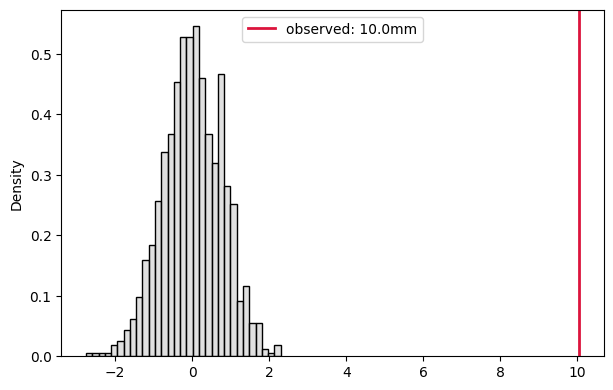

In [14]:
penguins = load_showcase("penguins").dropna(subset=["bill_length_mm"])
two = penguins[penguins["species"].isin(["Adelie", "Chinstrap"])]

observed = (
    two.loc[two["species"] == "Chinstrap", "bill_length_mm"].mean()
    - two.loc[two["species"] == "Adelie", "bill_length_mm"].mean()
)

values = two["bill_length_mm"].to_numpy()
labels = two["species"].to_numpy()
n_shuffles = 1000
null_diffs = np.empty(n_shuffles)
for i in range(n_shuffles):
    shuffled = rng.permutation(labels)
    null_diffs[i] = values[shuffled == "Chinstrap"].mean() - values[shuffled == "Adelie"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
host = HistogramPlot(PlotSettings(title="Null distribution of the species difference", xlabel="Chinstrap - Adelie (mm)"))
host.fig, host.ax = fig, ax
host.build(null_diffs, color="lightgrey")
ax.axvline(observed, color="crimson", linewidth=2, label=f"observed: {observed:.1f}mm")
ax.legend()

p_value = (np.abs(null_diffs) >= abs(observed)).mean()
print(f"observed difference: {observed:.2f}mm")
print(f"shuffled differences this extreme or more: {p_value:.4f}")

The observed difference sits nowhere near the shuffled-label distribution — reshuffling
species at random essentially never produces a gap this large. This is the mechanism a
formal permutation test runs; the histogram is what the p-value is a summary *of*.

## 4.6 Does sample size matter? Run the same estimate at four sizes

A real effect and a shuffled (fake) one, both estimated from n = 10, 30, 100, and 300 —
watch how the estimate's spread narrows around the true value for the real effect, and
around zero for the fake one, and how indistinguishable the two are at n=10.

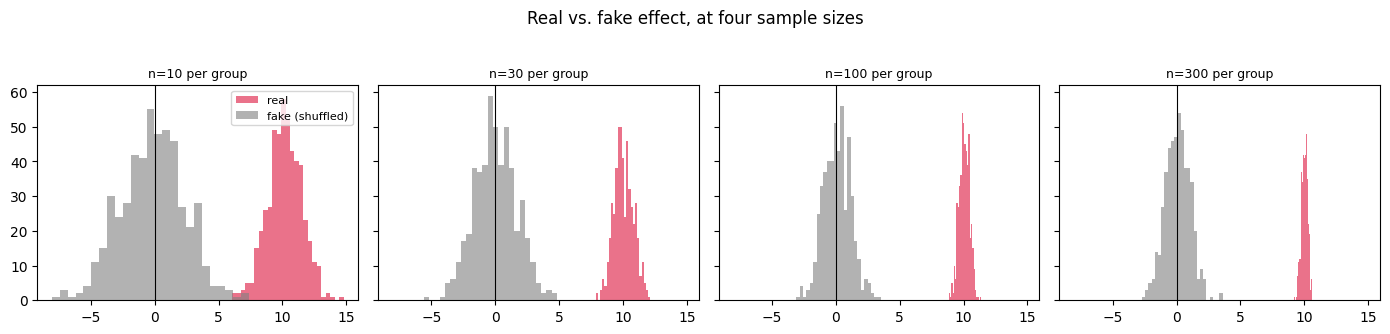

In [15]:
def bootstrap_diff(values, labels, n_per_group, n_boot=500, shuffle=False):
    out = np.empty(n_boot)
    for i in range(n_boot):
        use_labels = rng.permutation(labels) if shuffle else labels
        a = rng.choice(values[use_labels == "Chinstrap"], size=n_per_group, replace=True)
        b = rng.choice(values[use_labels == "Adelie"], size=n_per_group, replace=True)
        out[i] = a.mean() - b.mean()
    return out


sizes = [10, 30, 100, 300]
fig, axes = plt.subplots(1, len(sizes), figsize=(14, 3.2), sharex=True, sharey=True)
for ax, n in zip(axes, sizes):
    real = bootstrap_diff(values, labels, n)
    fake = bootstrap_diff(values, labels, n, shuffle=True)
    ax.hist(real, bins=25, alpha=0.6, color="crimson", label="real")
    ax.hist(fake, bins=25, alpha=0.6, color="gray", label="fake (shuffled)")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"n={n} per group", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("Real vs. fake effect, at four sample sizes", y=1.03)
fig.tight_layout()

At n=10 the two distributions overlap almost entirely — a study that size cannot tell a
real 10mm difference from noise. By n=100 they have pulled apart cleanly. Sample size is
not a formality; it is the difference between "we found something" and "we found nothing
and did not notice."

## Reflection

1. Pick one distribution from §4.1's gallery and name a variable from your own chat you
   would expect to follow it. What would have to be true about *how the variable is
   generated* for that expectation to hold?
2. In §4.3, the log-transform turned an "outlier" into an ordinary observation. Can you
   think of a case in your own data where the reverse would be true — where log-transforming
   would turn an ordinary point into a suspicious one?
3. §4.4's IRC-resolution caveat is a case of the tool determining the question. What is one
   other question in this course you could not have asked with minute-resolution
   timestamps, that second-resolution data makes possible?
4. In §4.6, at what sample size would you personally trust the estimate enough to report
   it? Justify the number, not just the vibe.